In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants, units
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Species names

In [4]:
O_list = ['OI', 'OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX']

O_species = [r'$\mathrm{O}^0$', r'$\mathrm{O}^+$', r'$\mathrm{O}^{2+}$', r'$\mathrm{O}^{3+}$',
            r'$\mathrm{O}^{4+}$', r'$\mathrm{O}^{5+}$', r'$\mathrm{O}^{6+}$',
            r'$\mathrm{O}^{7+}$', r'$\mathrm{O}^{8+}$']

In [5]:
C_list = ['CI', 'CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII']

C_species = [r'$\mathrm{C}^0$', r'$\mathrm{C}^+$', r'$\mathrm{C}^{2+}$', r'$\mathrm{C}^{3+}$',
            r'$\mathrm{C}^{4+}$', r'$\mathrm{C}^{5+}$', r'$\mathrm{C}^{6+}$', r'$\mathrm{C}^{6+}$'] 

In [6]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'goldenrod']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

# Ion by ion cooling efficiencies

## Oxygen

In [7]:
T_grid = 10**np.arange(4, 8.02, 0.02)

Load in cooling due to collisional ionization + free-free

In [8]:
lam_dict_init = {s:np.loadtxt(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/{}/coll t6.cool'.format(s), skiprows=1)[:,2] for s in O_list}

In [9]:
#lam_dict

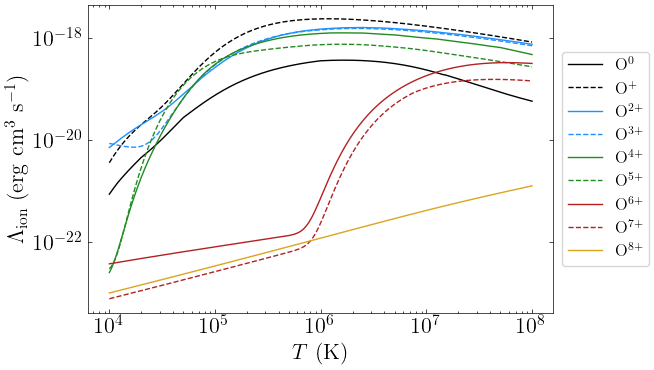

In [10]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid, lam_dict_init[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=O_species[i])
    
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')
    
#ax.set_xlim(10**4,10**6.9)
#ax.set_ylim(10**-2.9, 10**0.3)

Load in cooling due to recombination

In [11]:
lam_dict_rec = {s:np.zeros(len(T_grid)) for s in O_list}

In [12]:
for i in range(1, len(O_list)):
    
    s = O_list[i]
    
    # Load in the recombination file
    with open(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/{}/recomb t6.cool'.format(s)) as f:
        L = f.readlines()
        
    # Read in lines with temperatures and recombination coefficients
    te_str_list = [l for l in L if 'recombination coefficients' in l][1:] # First line is a title
    rad_rec_str_list = [l for l in L if 'radiative used' in l]
    
    # Isolate temperatures and recombination coefficients by splitting strings appropriately
    te_list = [float(l.split('\t')[2]) for l in te_str_list]
    rad_rec_list = [float(l.split(' ')[-5]) for l in rad_rec_str_list]
    
    # Isolate unique temperatures and recombination coefficients
    te_unique = []
    rad_rec_unique = []

    for i in range(len(te_list)-1):

        if te_list[i]!=te_list[i+1]:
            te_unique.append(te_list[i])
            rad_rec_unique.append(rad_rec_list[i])

    te_unique.append(te_list[-1]) # Need to manually add last entry
    rad_rec_unique.append(rad_rec_unique[-1])

    te_unique = np.array(te_unique)
    rad_rec_unique = np.array(rad_rec_unique)
    
    # Compute recombination cooling, multiply kT (in erg) with recombination coefficient
    lam_dict_rec[s] = ((constants.k_B*te_unique*units.K).to(units.erg).value)*rad_rec_unique

Generate total cooling

In [13]:
lam_dict = {s:lam_dict_init[s]+lam_dict_rec[s] for s in O_list}

In [14]:
with open(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/lam_oxy.pkl', 'wb') as f:
    pickle.dump(lam_dict, f)

Load in the cooling efficiencies for Gnat and Ferland 2012

In [15]:
gf12_table = np.loadtxt(rootdir+'gf12_grids/table1h.dat')

(1e-24, 5e-17)

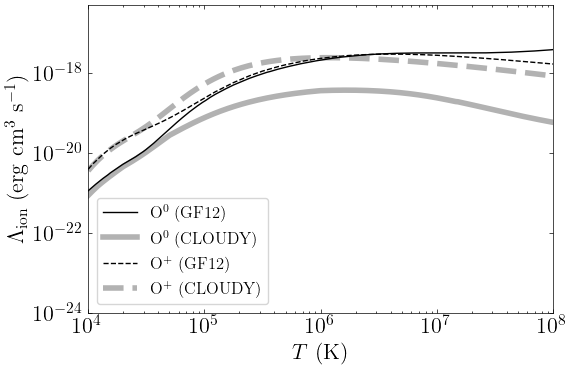

In [16]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,1], 
            color=colors_list[0], 
            linestyle = ls_list[0], label=O_species[0]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[0]], 
        color=colors_list[0], 
        linestyle = ls_list[0], label=O_species[0]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,2], 
            color=colors_list[1], 
            linestyle = ls_list[1], label=O_species[1]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[1]], 
        color=colors_list[1], 
        linestyle = ls_list[1], label=O_species[1]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 5e-17)

(1e-24, 4e-18)

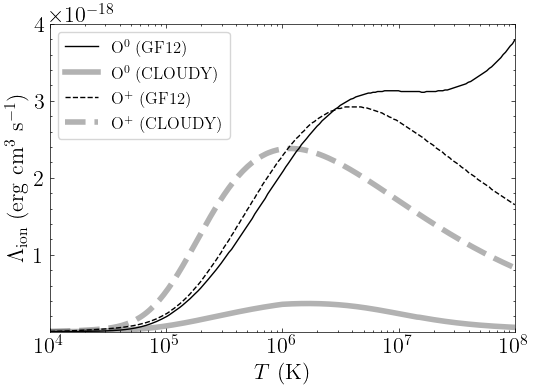

In [17]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,1], 
            color=colors_list[0], 
            linestyle = ls_list[0], label=O_species[0]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[0]], 
        color=colors_list[0], 
        linestyle = ls_list[0], label=O_species[0]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,2], 
            color=colors_list[1], 
            linestyle = ls_list[1], label=O_species[1]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[1]], 
        color=colors_list[1], 
        linestyle = ls_list[1], label=O_species[1]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 4e-18)

(1e-24, 5e-17)

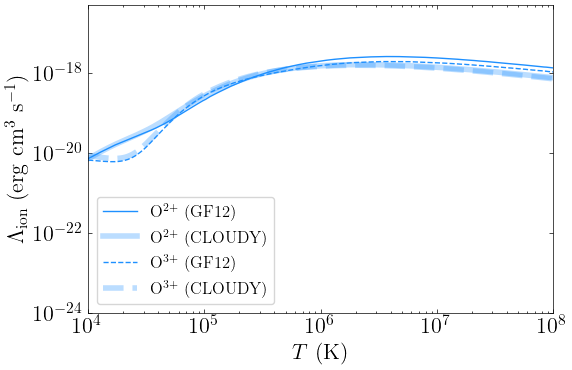

In [18]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,3], 
            color=colors_list[2], 
            linestyle = ls_list[2], label=O_species[2]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[2]], 
        color=colors_list[2], 
        linestyle = ls_list[2], label=O_species[2]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,4], 
            color=colors_list[3], 
            linestyle = ls_list[3], label=O_species[3]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[3]], 
        color=colors_list[3], 
        linestyle = ls_list[3], label=O_species[3]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 5e-17)

(1e-24, 3e-18)

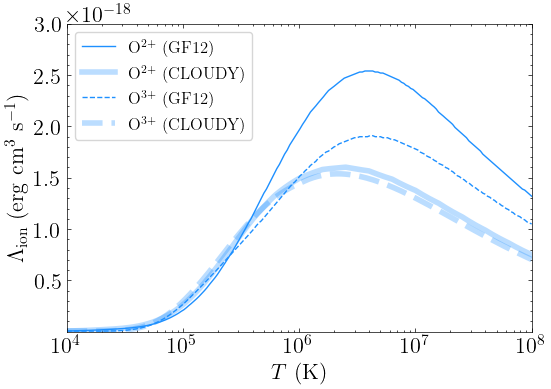

In [19]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,3], 
            color=colors_list[2], 
            linestyle = ls_list[2], label=O_species[2]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[2]], 
        color=colors_list[2], 
        linestyle = ls_list[2], label=O_species[2]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,4], 
            color=colors_list[3], 
            linestyle = ls_list[3], label=O_species[3]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[3]], 
        color=colors_list[3], 
        linestyle = ls_list[3], label=O_species[3]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 3e-18)

(1e-24, 5e-17)

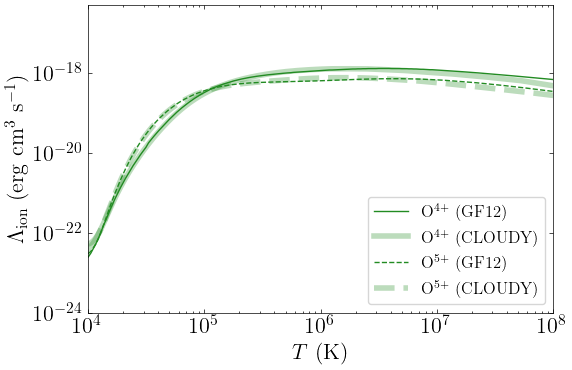

In [20]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,5], 
            color=colors_list[4], 
            linestyle = ls_list[4], label=O_species[4]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[4]], 
        color=colors_list[4], 
        linestyle = ls_list[4], label=O_species[4]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,6], 
            color=colors_list[5], 
            linestyle = ls_list[5], label=O_species[5]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[5]], 
        color=colors_list[5], 
        linestyle = ls_list[5], label=O_species[5]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 5e-17)

(1e-24, 1.8e-18)

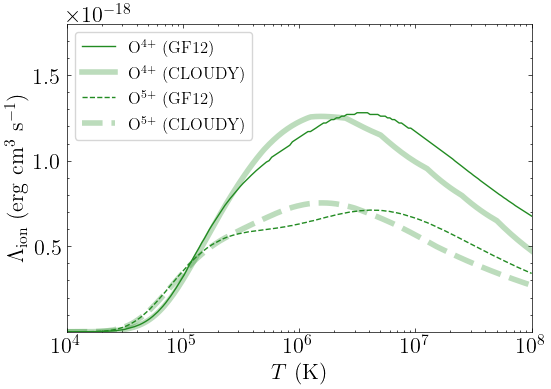

In [21]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,5], 
            color=colors_list[4], 
            linestyle = ls_list[4], label=O_species[4]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[4]], 
        color=colors_list[4], 
        linestyle = ls_list[4], label=O_species[4]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,6], 
            color=colors_list[5], 
            linestyle = ls_list[5], label=O_species[5]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[5]], 
        color=colors_list[5], 
        linestyle = ls_list[5], label=O_species[5]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 1.8e-18)

(1e-24, 5e-17)

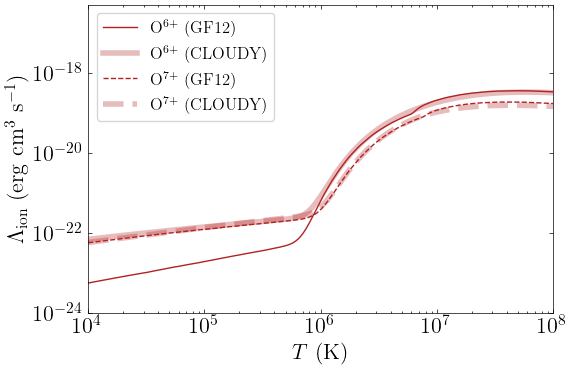

In [22]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,7], 
            color=colors_list[6], 
            linestyle = ls_list[6], label=O_species[6]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[6]], 
        color=colors_list[6], 
        linestyle = ls_list[6], label=O_species[6]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,8], 
            color=colors_list[7], 
            linestyle = ls_list[7], label=O_species[7]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[7]], 
        color=colors_list[7], 
        linestyle = ls_list[7], label=O_species[7]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 5e-17)

(1e-24, 4e-19)

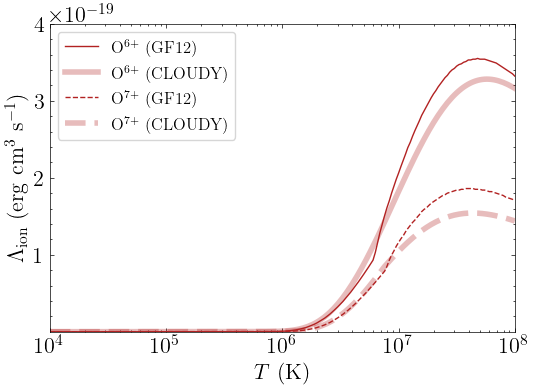

In [23]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,7], 
            color=colors_list[6], 
            linestyle = ls_list[6], label=O_species[6]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[6]], 
        color=colors_list[6], 
        linestyle = ls_list[6], label=O_species[6]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,8], 
            color=colors_list[7], 
            linestyle = ls_list[7], label=O_species[7]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[7]], 
        color=colors_list[7], 
        linestyle = ls_list[7], label=O_species[7]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 4e-19)

(1e-24, 5e-17)

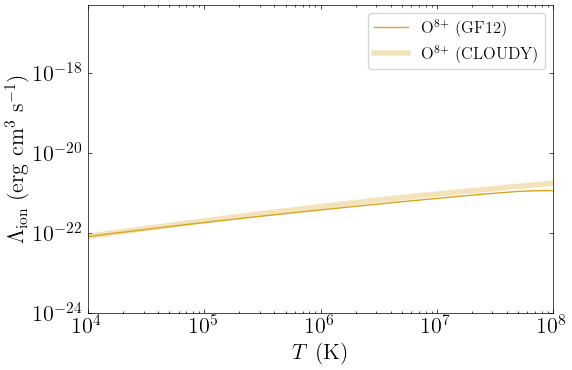

In [24]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,9], 
            color=colors_list[8], 
            linestyle = ls_list[8], label=O_species[8]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[8]], 
        color=colors_list[8], 
        linestyle = ls_list[8], label=O_species[8]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 5e-17)

(1e-24, 2e-21)

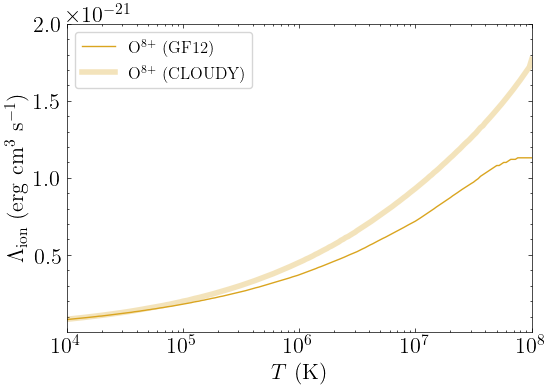

In [25]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,9], 
            color=colors_list[8], 
            linestyle = ls_list[8], label=O_species[8]+' (GF12)')
    
ax.plot(T_grid, lam_dict[O_list[8]], 
        color=colors_list[8], 
        linestyle = ls_list[8], label=O_species[8]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 2e-21)

In [26]:
x_list = [2e+4, 2e+4, 2e+4, 2e+4, 1e+7, 1e+7, 1e+7, 1e+7, 1e+7]
y_list = [7e-22, 1e-19, 1e-19, 9e-22, 2e-18, 1e-19, 2e-20, 4e-19, 1e-22]

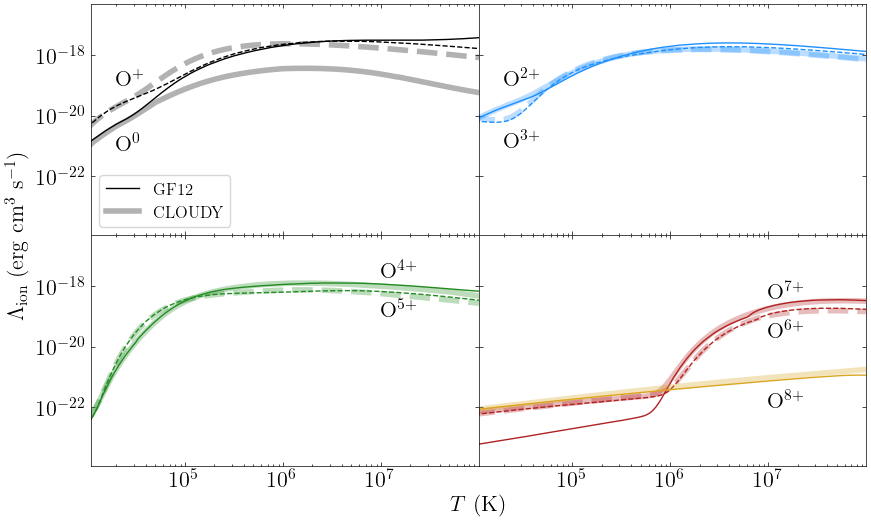

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(5*2, 3*2), sharex=True, sharey=True)

# OI and OII

axes[0,0].plot(gf12_table[:,0], gf12_table[:,1], 
            color=colors_list[0], 
            linestyle = ls_list[0], label='GF12')
    
axes[0,0].plot(T_grid, lam_dict[O_list[0]], 
        color=colors_list[0], 
        linestyle = ls_list[0], label='CLOUDY', lw=4, alpha=.3)

axes[0,0].text(x_list[0], y_list[0], O_species[0])
    
axes[0,0].plot(gf12_table[:,0], gf12_table[:,2], 
            color=colors_list[1], 
            linestyle = ls_list[1])
    
axes[0,0].plot(T_grid, lam_dict[O_list[1]], 
        color=colors_list[1], 
        linestyle = ls_list[1], lw=4, alpha=.3)    

axes[0,0].text(x_list[1], y_list[1], O_species[1])

axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

axes[0,0].legend()

axes[0,0].set_xlim(1.1e+4, 9.9e+7)
axes[0,0].set_ylim(1.1e-24, 4.9e-17)

# OIII and OIV

axes[0,1].plot(gf12_table[:,0], gf12_table[:,3], 
            color=colors_list[2], 
            linestyle = ls_list[2], label='GF12')
    
axes[0,1].plot(T_grid, lam_dict[O_list[2]], 
        color=colors_list[2], 
        linestyle = ls_list[2], label='CLOUDY', lw=4, alpha=.3)

axes[0,1].text(x_list[2], y_list[2], O_species[2])

    
axes[0,1].plot(gf12_table[:,0], gf12_table[:,4], 
            color=colors_list[3], 
            linestyle = ls_list[3])
    
axes[0,1].plot(T_grid, lam_dict[O_list[3]], 
        color=colors_list[3], 
        linestyle = ls_list[3], lw=4, alpha=.3) 

axes[0,1].text(x_list[3], y_list[3], O_species[3])

#axes[0,1].legend()

# OV and OVI

axes[1,0].plot(gf12_table[:,0], gf12_table[:,5], 
            color=colors_list[4], 
            linestyle = ls_list[4], label=O_species[4]+' (GF12)')
    
axes[1,0].plot(T_grid, lam_dict[O_list[4]], 
        color=colors_list[4], 
        linestyle = ls_list[4], label=O_species[4]+' (CLOUDY)', lw=4, alpha=.3)

axes[1,0].text(x_list[4], y_list[4], O_species[4])
    
axes[1,0].plot(gf12_table[:,0], gf12_table[:,6], 
            color=colors_list[5], 
            linestyle = ls_list[5], label=O_species[5]+' (GF12)')
    
axes[1,0].plot(T_grid, lam_dict[O_list[5]], 
        color=colors_list[5], 
        linestyle = ls_list[5], label=O_species[5]+' (CLOUDY)', lw=4, alpha=.3)    

axes[1,0].text(x_list[5], y_list[5], O_species[5])

#axes[1,0].legend()

# OVII, OVIII, and OIX

axes[1,1].plot(gf12_table[:,0], gf12_table[:,7], 
            color=colors_list[6], 
            linestyle = ls_list[6], label=O_species[6]+' (GF12)')
    
axes[1,1].plot(T_grid, lam_dict[O_list[6]], 
        color=colors_list[6], 
        linestyle = ls_list[6], label=O_species[6]+' (CLOUDY)', lw=4, alpha=.3)

axes[1,1].text(x_list[6], y_list[6], O_species[6])

    
axes[1,1].plot(gf12_table[:,0], gf12_table[:,8], 
            color=colors_list[7], 
            linestyle = ls_list[7], label=O_species[7]+' (GF12)')
    
axes[1,1].plot(T_grid, lam_dict[O_list[7]], 
        color=colors_list[7], 
        linestyle = ls_list[7], label=O_species[7]+' (CLOUDY)', lw=4, alpha=.3)    

axes[1,1].text(x_list[7], y_list[7], O_species[7])

axes[1,1].plot(gf12_table[:,0], gf12_table[:,9], 
            color=colors_list[8], 
            linestyle = ls_list[8], label=O_species[8]+' (GF12)')
    
axes[1,1].plot(T_grid, lam_dict[O_list[8]], 
        color=colors_list[8], 
        linestyle = ls_list[8], label=O_species[8]+' (CLOUDY)', lw=4, alpha=.3)

axes[1,1].text(x_list[8], y_list[8], O_species[8])

#axes[1,1].legend()

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$T \ (\mathrm{K})$', labelpad=20)
ax_label.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$', labelpad=45)

plt.subplots_adjust(wspace=0, hspace=0)

## Carbon

In [28]:
T_grid = 10**np.arange(4, 8.2, 0.2)

Load in cooling due to collisional ionization + free-free

In [29]:
lam_dict_init = {s:np.loadtxt(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/{}/coll t6.cool'.format(s), skiprows=1)[:,2] for s in C_list}

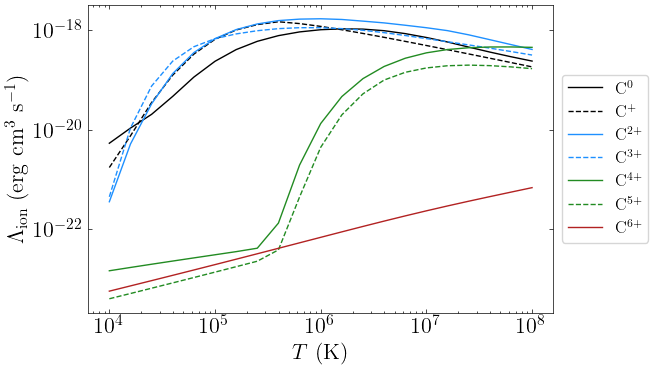

In [30]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(C_list)):
    
    s = C_list[i]
    
    
    ax.plot(T_grid, lam_dict_init[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=C_species[i])
    
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')
    
#ax.set_xlim(10**4,10**6.9)
#ax.set_ylim(10**-2.9, 10**0.3)

Load in cooling due to recombination

In [31]:
lam_dict_rec = {s:np.zeros(len(T_grid)) for s in C_list}

In [32]:
for i in range(1, len(C_list)):
    
    s = C_list[i]
    
    # Load in the recombination file
    with open(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/{}/recomb t6.cool'.format(s)) as f:
        L = f.readlines()
        
    # Read in lines with temperatures and recombination coefficients
    te_str_list = [l for l in L if 'recombination coefficients' in l][1:] # First line is a title
    rad_rec_str_list = [l for l in L if 'radiative used' in l]
    
    # Isolate temperatures and recombination coefficients by splitting strings appropriately
    te_list = [float(l.split('\t')[2]) for l in te_str_list]
    rad_rec_list = [float(l.split(' ')[-5]) for l in rad_rec_str_list]
    
    # Isolate unique temperatures and recombination coefficients
    te_unique = []
    rad_rec_unique = []

    for i in range(len(te_list)-1):

        if te_list[i]!=te_list[i+1]:
            te_unique.append(te_list[i])
            rad_rec_unique.append(rad_rec_list[i])

    te_unique.append(te_list[-1]) # Need to manually add last entry
    rad_rec_unique.append(rad_rec_unique[-1])

    te_unique = np.array(te_unique)
    rad_rec_unique = np.array(rad_rec_unique)
    
    # Compute recombination cooling, multiply kT (in erg) with recombination coefficient
    lam_dict_rec[s] = ((constants.k_B*te_unique*units.K).to(units.erg).value)*rad_rec_unique

Generate total cooling

In [33]:
lam_dict = {s:lam_dict_init[s]+lam_dict_rec[s] for s in C_list}

In [34]:
with open(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/lam_carb.pkl', 'wb') as f:
    pickle.dump(lam_dict, f)

Load in the cooling efficiencies for Gnat and Ferland 2012

In [35]:
gf12_table = np.loadtxt(rootdir+'gf12_grids/table1f.dat')

In [36]:
#gf12_table

(1e-24, 1e-17)

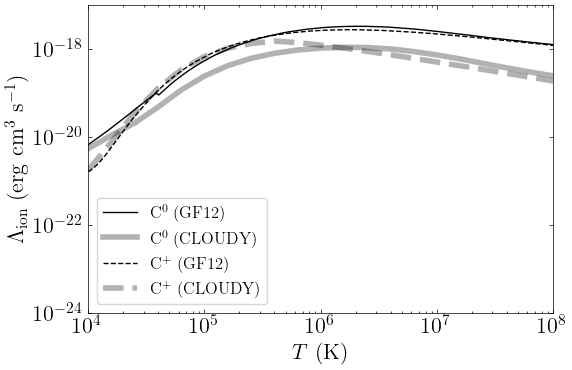

In [37]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,1], 
            color=colors_list[0], 
            linestyle = ls_list[0], label=C_species[0]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[0]], 
        color=colors_list[0], 
        linestyle = ls_list[0], label=C_species[0]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,2], 
            color=colors_list[1], 
            linestyle = ls_list[1], label=C_species[1]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[1]], 
        color=colors_list[1], 
        linestyle = ls_list[1], label=C_species[1]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 1e-17)

(1e-24, 1e-17)

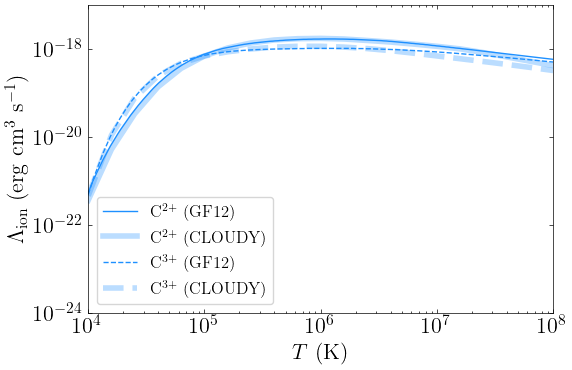

In [38]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,3], 
            color=colors_list[2], 
            linestyle = ls_list[2], label=C_species[2]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[2]], 
        color=colors_list[2], 
        linestyle = ls_list[2], label=C_species[2]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,4], 
            color=colors_list[3], 
            linestyle = ls_list[3], label=C_species[3]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[3]], 
        color=colors_list[3], 
        linestyle = ls_list[3], label=C_species[3]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 1e-17)

(1e-24, 1e-17)

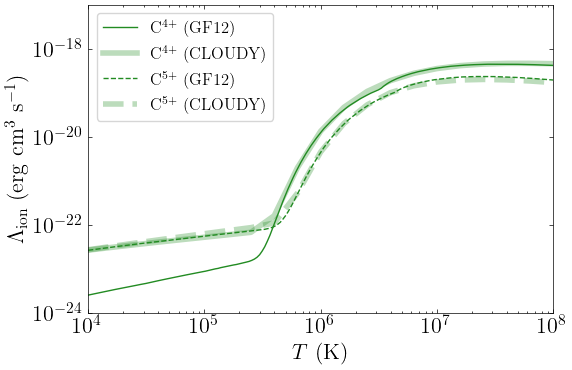

In [39]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,5], 
            color=colors_list[4], 
            linestyle = ls_list[4], label=C_species[4]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[4]], 
        color=colors_list[4], 
        linestyle = ls_list[4], label=C_species[4]+' (CLOUDY)', lw=4, alpha=.3)
    
ax.plot(gf12_table[:,0], gf12_table[:,6], 
            color=colors_list[5], 
            linestyle = ls_list[5], label=C_species[5]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[5]], 
        color=colors_list[5], 
        linestyle = ls_list[5], label=C_species[5]+' (CLOUDY)', lw=4, alpha=.3)    
    
ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 1e-17)

(1e-24, 1e-17)

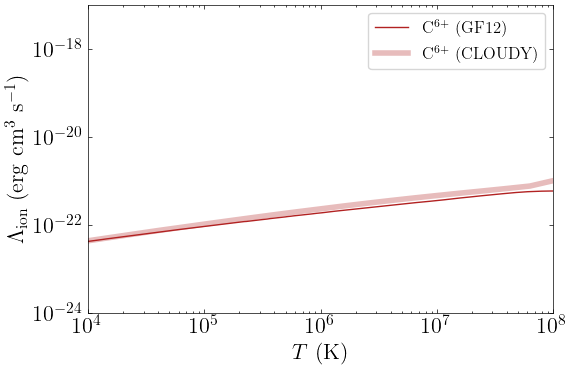

In [40]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.plot(gf12_table[:,0], gf12_table[:,7], 
            color=colors_list[6], 
            linestyle = ls_list[6], label=C_species[6]+' (GF12)')
    
ax.plot(T_grid, lam_dict[C_list[6]], 
        color=colors_list[6], 
        linestyle = ls_list[6], label=C_species[6]+' (CLOUDY)', lw=4, alpha=.3)

ax.legend()

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e+4, 1e+8)
ax.set_ylim(1e-24, 1e-17)

In [41]:
x_list = [2e+4, 2e+4, 2e+4, 2e+4, 1e+7, 1e+7, 1e+7]
y_list = [3e-21, 1e-19, 3e-19, 3e-21, 7e-19, 3e-20, 8e-22]

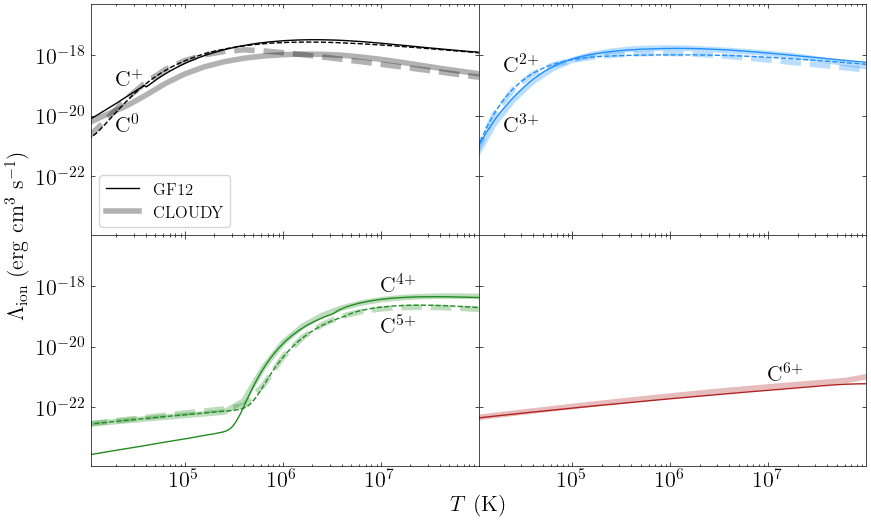

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(5*2, 3*2), sharex=True, sharey=True)

# CI and CII

axes[0,0].plot(gf12_table[:,0], gf12_table[:,1], 
            color=colors_list[0], 
            linestyle = ls_list[0], label='GF12')
    
axes[0,0].plot(T_grid, lam_dict[C_list[0]], 
        color=colors_list[0], 
        linestyle = ls_list[0], label='CLOUDY', lw=4, alpha=.3)

axes[0,0].text(x_list[0], y_list[0], C_species[0])
    
axes[0,0].plot(gf12_table[:,0], gf12_table[:,2], 
            color=colors_list[1], 
            linestyle = ls_list[1])
    
axes[0,0].plot(T_grid, lam_dict[C_list[1]], 
        color=colors_list[1], 
        linestyle = ls_list[1], lw=4, alpha=.3)    

axes[0,0].text(x_list[1], y_list[1], C_species[1])

axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

axes[0,0].legend()

axes[0,0].set_xlim(1.1e+4, 9.9e+7)
axes[0,0].set_ylim(1.1e-24, 4.9e-17)

# CIII and CIV

axes[0,1].plot(gf12_table[:,0], gf12_table[:,3], 
            color=colors_list[2], 
            linestyle = ls_list[2], label='GF12')
    
axes[0,1].plot(T_grid, lam_dict[C_list[2]], 
        color=colors_list[2], 
        linestyle = ls_list[2], label='CLOUDY', lw=4, alpha=.3)

axes[0,1].text(x_list[2], y_list[2], C_species[2])

    
axes[0,1].plot(gf12_table[:,0], gf12_table[:,4], 
            color=colors_list[3], 
            linestyle = ls_list[3])
    
axes[0,1].plot(T_grid, lam_dict[C_list[3]], 
        color=colors_list[3], 
        linestyle = ls_list[3], lw=4, alpha=.3) 

axes[0,1].text(x_list[3], y_list[3], C_species[3])

#axes[0,1].legend()

# CV and CVI

axes[1,0].plot(gf12_table[:,0], gf12_table[:,5], 
            color=colors_list[4], 
            linestyle = ls_list[4], label=C_species[4]+' (GF12)')
    
axes[1,0].plot(T_grid, lam_dict[C_list[4]], 
        color=colors_list[4], 
        linestyle = ls_list[4], label=C_species[4]+' (CLOUDY)', lw=4, alpha=.3)

axes[1,0].text(x_list[4], y_list[4], C_species[4])
    
axes[1,0].plot(gf12_table[:,0], gf12_table[:,6], 
            color=colors_list[5], 
            linestyle = ls_list[5], label=C_species[5]+' (GF12)')
    
axes[1,0].plot(T_grid, lam_dict[C_list[5]], 
        color=colors_list[5], 
        linestyle = ls_list[5], label=C_species[5]+' (CLOUDY)', lw=4, alpha=.3)    

axes[1,0].text(x_list[5], y_list[5], C_species[5])

#axes[1,0].legend()

# CVII

axes[1,1].plot(gf12_table[:,0], gf12_table[:,7], 
            color=colors_list[6], 
            linestyle = ls_list[6], label=C_species[6]+' (GF12)')
    
axes[1,1].plot(T_grid, lam_dict[C_list[6]], 
        color=colors_list[6], 
        linestyle = ls_list[6], label=C_species[6]+' (CLOUDY)', lw=4, alpha=.3)

axes[1,1].text(x_list[6], y_list[6], C_species[6])


#axes[1,1].legend()

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$T \ (\mathrm{K})$', labelpad=20)
ax_label.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$', labelpad=45)

#ax_label.set_title('Without recombination (default)')

plt.subplots_adjust(wspace=0, hspace=0)